In [1]:
import os
import re

import openai

from tqdm import tqdm
import pickle

import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

from collections import Counter
import matplotlib.pyplot as plt
import time


In [ ]:
openai.api_key =''
def generate_gpt4_response(content, print_output=False):
    response = openai.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "user", "content": content}
        ],
        temperature=0,
        top_p=0.1,
        n=1,
        # max_tokens=2000,  # Uncomment if you want to limit output length
        # stop=["###"],    # Uncomment if you want to specify stop tokens
    )

    if print_output:
        print(response)

    # Extract and return the first response
    return response.choices[0].message.content

In [3]:
def save_to_pickle(obj, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)

def load_from_pickle(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

In [4]:
def extract_clusters(folder_path):
    cluster_dict = {}
    
    # Retrieve all txt files in the folder
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    
    for file_name in txt_files:
        file_path = os.path.join(folder_path, file_name)
        
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
            
            # Extract cluster id
            cluster_match = re.search(r'Cluster (\d+) Terms:', content)
            if cluster_match:
                cluster_id = int(cluster_match.group(1))
                
                # Extract terms
                terms_match = re.search(r'Cluster \d+ Terms:\n(.+?)\n\n', content, re.DOTALL)
                if terms_match:
                    terms = terms_match.group(1).split('\n')
                    cluster_dict[cluster_id] = terms
    
    return cluster_dict


def check_abbreviation(cluster_dict, abbr_len=10):
    cluster_dict_abbr = {}
    for cid in cluster_dict.keys():
        keywords = cluster_dict[cid]
        average_length = sum(len(s) for s in keywords) / len(keywords)

        is_shorter_than_10 = average_length < abbr_len
        if is_shorter_than_10:
            cluster_dict_abbr[cid] = keywords
    return cluster_dict_abbr
    
            
def remove_abbreviation(cluster_dict, abbr_list):
    cluster_dict_cleaned = {}
    for cid in cluster_dict.keys():
        keywords = cluster_dict[cid]
        if cid not in abbr_list:
            cluster_dict_cleaned[cid] = keywords
    return cluster_dict_cleaned

# def remove_not_coherent_cluster(cluster_dict):
#     cluster_dict_cleaned = {}
#     for cid in tqdm(sorted(cluster_dict.keys())):
#         # print(cid)
#         keywords = cluster_dict[cid]
#         prompt = f"""
# {keywords}
# Please help determine if these terms focus on a coherent topic or not. Answer "yes" or "no" only.
# """
#         response = generate_gpt4_response(prompt)
#         response = response.strip(".").lower()
#         # print(response)
        
#         if response == 'yes':
#             cluster_dict_cleaned[cid] = [keywords]
            
#     return cluster_dict_cleaned

In [49]:
from pydantic import BaseModel, validator
from typing import Dict, List, Optional, Union
from tqdm import tqdm

openai_client = openai.OpenAI(api_key=openai.api_key)
# Corrected model for GPT response
class GPTClusterResponse(BaseModel):
    label: str
    subtopics: List[List[str]]

    @validator('label')
    def validate_label(cls, v):
        v = v.strip().lower()
        if v not in {"yes", "no"}:
            raise ValueError("label must be 'yes' or 'no'")
        return v

    @validator('subtopics')
    def validate_subtopics(cls, v, values):
        label = values.get('label')
        if label == "yes":
            if v is None or (isinstance(v, dict) and len(v) == 0):
                return {}
            else:
                raise ValueError("If label is 'yes', subtopics must be an empty dict or omitted")
        return v

def generate_gpt4_structured_response(content, print_output=False):
    response = openai_client.responses.parse(
        model="gpt-4o",
        input=[
            {
                "role": "user",
                "content": content,
            },
        ],
        text_format=GPTClusterResponse,
    )

    parsed_response = response.output_parsed

    if print_output:
        print(parsed_response)

    # Extract and return the first response
    return parsed_response

# Main clustering function
def break_cluster(cluster_dict: Dict[str, List[str]]) -> Dict[str, List[str]]:
    cluster_dict_cleaned = {}

    for cid in tqdm(sorted(cluster_dict.keys())):
        keywords = cluster_dict[cid]
        prompt = f"""
{keywords}
Please help determine if these terms focus on a coherent topic or not. Answer strictly in the following JSON format:

If the terms form a coherent topic:
{{
  "label": "yes",
  "subtopics": []
}}

If not:
{{
  "label": "no",
  "subtopics": [
    [list of keywords for topic 1],
    [list of keywords for topic 2],
    ...
  ]
}}
**Important**: If the answer is no, group the terms by subtopics. Do not add new terms or remove existing terms from the provided list of terms. 
"""

        # parsed = generate_gpt4_structured_response(prompt)

        try:
            parsed = generate_gpt4_structured_response(prompt)
            # print(type(parsed))
            # print(parsed)

            if parsed.label == "yes":
                cluster_dict_cleaned[cid] = [keywords]
            elif parsed.label == "no":
                # for i, sublist in enumerate(parsed.subtopics):
                cluster_dict_cleaned[cid] = parsed.subtopics

        except Exception as e:
            print(f"[Validation error] Cluster '{cid}': {e}")
            cluster_dict_cleaned[cid] = [keywords]
            continue

    return cluster_dict_cleaned


def break_cluster_postprocess(dict_original_clusters, dict_subclusters):
    dict_cleaned_subclusters = defaultdict(list)
    topic_ids = dict_original_clusters.keys()
    for idx in tqdm(topic_ids):
        keywords = dict_original_clusters[idx]
        # if idx not in dict_subclusters.keys():
        #     subclusters = [keywords]
        # else:
        subclusters = dict_subclusters[idx]

        seen = set()
        unique_subclusters = []
        for sub in subclusters:
            norm = tuple(sorted(sub))
            if norm not in seen:
                seen.add(norm)
                unique_subclusters.append(sub)
        
        subcluster_keywords = [keyword for keywords in unique_subclusters for keyword in keywords]
    

        #Find terms that have not been included
        keyword_not_included = []
        for keyword in keywords:
            if keyword not in subcluster_keywords:
                keyword_not_included.append(keyword)


                
        # assign terms to subclusters
        subcluster_keywords_embedding = generate_embeddings_in_batches(subcluster_keywords, batch_size=1)

        for keyword in keyword_not_included:
            original_keywords_embedding = generate_embeddings_in_batches(keyword, batch_size=1)[0, :]
            top_names, top_scores = get_top_k_similar(original_keywords_embedding, subcluster_keywords_embedding, subcluster_keywords, k=1)
            # print(keyword, top_names, top_scores)
            most_similar_name = top_names[0]

            for j, s in enumerate(unique_subclusters):
                if most_similar_name in s:
                    unique_subclusters[j].append(keyword)
                   
                    
        #Remove terms that do not exist
        filtered_subclusters = [[item for item in sublist if item in keywords] for sublist in unique_subclusters]
        filtered_subclusters = [sublist for sublist in filtered_subclusters if sublist]
        filtered_subclusters = [list(set(sublist)) for sublist in filtered_subclusters]

        seen = set()
        unique_filtered_subclusters = []
        for sub in filtered_subclusters:
            norm = tuple(sorted(sub))
            if norm not in seen:
                seen.add(norm)
                unique_filtered_subclusters.append(sub)
            
        dict_cleaned_subclusters[idx] = unique_filtered_subclusters
    return dict_cleaned_subclusters
        

/tmp/ipykernel_3703931/758776142.py:11: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('label')
/tmp/ipykernel_3703931/758776142.py:18: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('subtopics')


In [6]:
def load_keywords_sheet(file_path):
    sheet_name = "New Test Cleaned Keywords + Pap"
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        return df
    except Exception as e:
        print(f"Error loading sheet: {e}")
        return None


def count_papers_per_keyword(df, topic_dict, year_col="Year", keyword_col="Keywords"):
    from collections import defaultdict, Counter
    topic_year_count = defaultdict(int)

    # Preprocess topic terms for faster matching (optional: lowercasing)
    topic_terms = {}
    for cid, keyword_list in topic_dict.items():
        for idx, keywords in enumerate(keyword_list):
            topic_terms[f"{cid}-{idx}"] = set(keyword.lower() for keyword in keywords)
        
    dict_keywords = Counter()
    for _, row in df.iterrows():
        keywords = row.get(keyword_col)

        if pd.isna(keywords):
            continue

        # Lowercase + split if keywords are separated (adjust if needed)
        keyword_list = [kw.strip().lower() for kw in str(keywords).split(",")]
        for keyword in keyword_list:
            dict_keywords[keyword] += 1

    topic_keyword_count = defaultdict(dict)
    for topic_id, term_set in topic_terms.items():
        for keyword in term_set:
            if keyword in dict_keywords:
                topic_keyword_count[topic_id][keyword] = dict_keywords[keyword]
        
        
    return topic_keyword_count

def convert_counts_to_proportions(topic_keyword_count):
    topic_keyword_proportion = {}

    for topic_id, keywords in topic_keyword_count.items():
        total = sum(keywords.values())
        if total == 0:
            topic_keyword_proportion[topic_id] = {kw: 0.0 for kw in keywords}
        else:
            topic_keyword_proportion[topic_id] = {
                kw: count / total for kw, count in keywords.items()
            }

    return topic_keyword_proportion


In [7]:
"""
{'1-1':{'keyword1':0.01, ....}}
"""
def generate_name(keyword_distribution, domain='method'):

    if len(keyword_distribution)==1:
        name = list(keyword_distribution.keys())[0]

    if domain=='method':
        prompt = f"""
Please use 1 precise and succinct phrase in no more than 3 words to summarize the main topic of the following list of keywords in the methodology domain based on their distribution:
{keyword_distribution}
"""
    else:
        prompt = f"""
Please use 1 precise and succinct phrase in no more than 3 words to summarize the main topic of the following list of keywords in the health domain based on their distribution:
{keyword_distribution}
"""
        
    name = generate_gpt4_response(prompt).rstrip('.')
    return name

def get_top_k_similar(embedding, embeddings, names, k=5):
    embedding = embedding.reshape(1, -1)
    similarities = cosine_similarity(embedding, embeddings)[0]
    top_k_indices = np.argsort(similarities)[::-1][:k]
    top_k_names = [names[i] for i in top_k_indices]
    top_k_scores = [similarities[i] for i in top_k_indices]
    return top_k_names, top_k_scores



def check_existing_names_suitability(name, similar_names, keyword_distribution, domain, max_retries=5):    
    phrase_str = ''
    for idx, s_name in enumerate(similar_names):
        phrase_str += f'{idx}. {s_name}\n'

    if domain == 'method':
        prompt = f"""
        Please check if any of these phrases can summarize the main topic of the following list of keywords in the methodology domain based on their distribution:
        {keyword_distribution}
        Here is the list of phrases:
        {phrase_str}
    
        Return the ID only of the top 1 suitable phrase without providing the rationale. If none, return none only. 
        """
    else:
        prompt = f"""
        Please check if any of these phrases can summarize the main topic of the following list of keywords in the health domain based on their distribution:
        {keyword_distribution}
        Here is the list of phrases:
        {phrase_str}
    
        Return the ID only of the top 1 suitable phrase without providing the rationale. If none, return none only. 
        """
    for attempt in range(max_retries):
        response = generate_gpt4_response(prompt).strip().rstrip('.').lower()

        if response[:4] == 'none':
            return name
        elif response[0].isdigit():
            idx = int(response[0])
            if 0 <= idx < len(similar_names):
                return similar_names[idx]
        
        # Retry on invalid response
        print(f"Invalid response '{response}', retrying ({attempt+1}/{max_retries})...")

    # Fallback if no valid response is received
    return name
    
    
def topic_naming(dict_topic_keyword, domain, similarity_threshold=0, k=3):

    embeddings = np.empty((0, 768))  # Adjust dimension to your embedding size
    names = []
    dict_topic_id2name = {}
    for tid, keyword_distribution in tqdm(dict_topic_keyword.items()):

        name = generate_name(keyword_distribution, domain)
        
        embedding = generate_embeddings_in_batches(name, batch_size=1)[0, :]  # shape (768,)
        if name in names:
            dict_topic_id2name[tid] = name
            continue
        if len(names) == 0:
            names.append(name)
            embeddings = np.vstack([embeddings, embedding])
            dict_topic_id2name[tid] = name
        else:
            top_k_names, top_k_scores = get_top_k_similar(embedding, embeddings, names, k=k)
            # print(top_k_names, top_k_scores)
            
            if top_k_scores[0] < similarity_threshold:  # Check if it's dissimilar enough to be new
                names.append(name)
                embeddings = np.vstack([embeddings, embedding])
                dict_topic_id2name[tid] = name
            else:
                selected_name = check_existing_names_suitability(name, top_k_names, keyword_distribution, domain)
                # print('selected_name', selected_name)
                if selected_name not in names:
                    names.append(selected_name)
                    embeddings = np.vstack([embeddings, embedding])
                dict_topic_id2name[tid] = selected_name
    return dict_topic_id2name
    


In [8]:
# from enum import Enum
# from pydantic import BaseModel

# import json


# class SetRelation(Enum):
#     SUPERSET = "Superset"
#     EQUAL = "Equal"
#     SUBSET = "Subset"
#     NO_OVERLAP = "NoOverlap"


# class PairwiseRelation(BaseModel):
#     topic_a: str
#     topic_b: str
#     relation: SetRelation




# def extract_topic_relationship_o3mini(topic_a, topic_b):
#     system_prompt = (
#         """
#         Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
#         - Superset: Topic B is a Topic A.
#         - Subset: Topic A is a Topic B.
#         - Equal: Topic A and B are synonyms
#         - NoOverlap: The two topics are conceptually distinct.
        
        
#         Return your response in the specified format.
#         """
#     )



#     user_prompt = f"Topic A: {topic_a}\nTopic B: {topic_b}"

#     response = openai_client.beta.chat.completions.parse(
#         model="o3-mini",
#         messages=[
#            {"role": "system", "content": system_prompt},
#            {"role": "user", "content": user_prompt}
#         ],
#         response_format=PairwiseRelation,
#     )
#     raw_json = response.choices[0].message.content
#     parsed = json.loads(raw_json)
#     return PairwiseRelation(**parsed)


In [9]:
# def extract_topic_relationship(topic_a, topic_b):
#     prompt = (
#         f"""
#         Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
#         Superset: Topic B is a Topic A.
#         Subset: Topic A is a Topic B.
#         Equal: Topic A and B are synonyms
#         NoOverlap: The two topics are conceptually distinct.
        
#         Here are the topics:
#         Topic A: {topic_a}\nTopic B: {topic_b}
        
#         Return the label only.
#         """
#     )

#     response = generate_gpt4_response(prompt)
#     return response.strip(".").lower()

In [10]:

def combine_topic_w_same_name(original_dict):
    from nltk.stem import PorterStemmer
    from collections import defaultdict
    stemmer = PorterStemmer()

    unique_values = defaultdict(list)
    for k, v in original_dict.items():
        stemmed = ' '.join([stemmer.stem(word.lower()) for word in v.split()])
        unique_values[stemmed].append(k)
            

    return unique_values
    

In [11]:
from sentence_transformers import SentenceTransformer, util
from typing import List
import numpy as np

embedder = SentenceTransformer('all-mpnet-base-v2')

def generate_embeddings_in_batches(
    texts,
    batch_size= 1024
):
    """
    Generate sentence embeddings in batches.
    
    Args:
        texts (List[str]): List of input text strings.
        model_name (str): Pretrained SentenceTransformer model name.
        batch_size (int): Number of texts to process per batch.
    
    Returns:
        np.ndarray: Array of embeddings.
    """
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        batch_embeddings = embedder.encode(batch, convert_to_numpy=True)
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)


/home/yf2505@mc.cumc.columbia.edu/anaconda3/envs/TopicTrend/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
def compute_pairwise_cosine_similarity(topic_names):
    embeddings = generate_embeddings_in_batches(topic_names)
    # Compute full cosine similarity matrix
    print('computing cosine similarity...')
    similarity_matrix = cosine_similarity(embeddings)
    
    # Create dictionary of pairwise similarities (i < j to avoid duplicates)
    similarity_dict = {}
    n = similarity_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            similarity_dict[(topic_names[i], topic_names[j])] = similarity_matrix[i, j]
    
    return similarity_dict


def compute_topic_similarity(high_level_topics, low_level_root_topics):
    # Combine all topics to get embeddings in one pass
    all_topics = high_level_topics + low_level_root_topics
    embeddings = generate_embeddings_in_batches(all_topics)
    
    # Compute cosine similarity matrix
    print('computing cosine similarity...')
    similarity_matrix = cosine_similarity(embeddings)
    
    # Build a mapping from topic name to index in the combined embeddings
    topic_to_index = {topic: idx for idx, topic in enumerate(all_topics)}
    
    similarity_dict = {}
    
    # Similarity between high-level topics
    for i in range(len(high_level_topics)):
        for j in range(i + 1, len(high_level_topics)):
            t1 = high_level_topics[i]
            t2 = high_level_topics[j]
            similarity_dict[(t1, t2)] = similarity_matrix[topic_to_index[t1], topic_to_index[t2]]
    
    # Similarity between high-level and low-level topics (high level topic, low level topic)
    for t1 in high_level_topics:
        for t2 in low_level_root_topics:
            similarity_dict[(t1, t2)] = similarity_matrix[topic_to_index[t1], topic_to_index[t2]]
    
    return similarity_dict

In [13]:
def have_relationship(topic1, topic2):
    prompt = (
        f"""
        Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
        Superset: Topic B is a subcategory of Topic A, but Topic A is not a subcategory of Topic B.
        Subset: Topic A is a subcategory of Topic B, but Topic B is not a subcategory of Topic A.
        Equal: Topic A is a Topic B and Topic B is a Topic A.
        NoOverlap: The two topics are conceptually distinct.
        
        Here are the topics:
        Topic A: {topic1}\nTopic B: {topic2}
        
        Return the label only.
        """
    )
    # print("##")
    # print(topic1,"--", topic2)
    response = generate_gpt4_response(prompt)
    # print(response)
    if response.strip(".").lower()!='nooverlap':
        return True
    else:
        return False
def find_threshold_by_pct(topic_dict, n_subset_topic1 = 200, precision=1e-3):
    # import random

    # Step 1: Group by topic1
    topic_groups = defaultdict(list)
    for (t1, t2), score in topic_dict.items():
        topic_groups[t1].append((t2, score))

    
    all_topic1 = list(topic_groups.keys())
    subset_topic_groups = {t1: topic_groups[t1] for t1 in all_topic1[:n_subset_topic1]}
    # all_topic1 = list(topic_groups.keys())
    # sample_size = min(n_subset_topic1, len(all_topic1))
    # random.seed(42)
    # selected_topic1 = random.sample(all_topic1, sample_size)
    # # Optionally extract the subset
    # subset_topic_groups = {t1: topic_groups[t1] for t1 in selected_topic1}
    
    thresholds = {}

    # Step 2 & 3: Binary search over pct [0.0, 1.0]
    for topic1, topic2_scores in tqdm(subset_topic_groups.items()):
        sorted_topic2s = sorted(topic2_scores, key=lambda x: x[1], reverse=False)
        # Extract just topic2 names
        sorted_topic2_names = [t2 for t2, _ in sorted_topic2s]
        sorted_topic2_scores = [s for _, s in sorted_topic2s]
        
        n = len(sorted_topic2_names)
        low, high = 0, 1.0
        best_pct = 0

        # has_relation, prev_has_relation = None, None
        prev_topic2 = None
        while high - low > precision:
            mid_pct = (low + high) / 2
            k = max(1, int(mid_pct * n))  # at least one
            selected_topic2 = sorted_topic2_names[k - 1]
            selected_score2 = sorted_topic2_scores[k-1]

            has_relation = have_relationship(topic1, selected_topic2)
            if has_relation:
                # print(topic1, "--", selected_topic2, 'yes', mid_pct, 'sim:',selected_score2)
                best_pct = mid_pct
                high = mid_pct
            else:
                # print(topic1, "--", selected_topic2, 'no', mid_pct, 'sim:', selected_score2)
                low = mid_pct
            
            # if prev_has_relation is not None:
            #     if has_relation != prev_has_relation:
            #         break
            # prev_has_relation = has_relation

            if prev_topic2 == selected_topic2:
                break
            else:
                prev_topic2 = selected_topic2
            
                

        
        thresholds[topic1] = best_pct

    return thresholds

def check_relationship(topic1, topic2, max_retries=5, retry_delay=1):
    prompt = (
        f"""
        Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
        Superset: Topic B is a subcategory of Topic A, but Topic A is not a subcategory of Topic B.
        Subset: Topic A is a subcategory of Topic B, but Topic B is not a subcategory of Topic A.
        Equal: Topic A is a Topic B and Topic B is a Topic A.
        NoOverlap: The two topics are conceptually distinct.
        
        Here are the topics:
        Topic A: {topic1}\nTopic B: {topic2}
        
        Return the label only.
        """
    )
    for attempt in range(max_retries):
        try:
            response = generate_gpt4_response(prompt)
            if response:
                return response.strip(".").lower()
        except Exception as e:
            # Optional: log the exception e
            pass
        time.sleep(retry_delay)  # Wait before retrying
    
    # If all attempts fail, return a default
    return "nooverlap"

def check_topic_relation(topic_dict, topic_prop_thresholds, lowest_threshold):
    # Step 1: Group by topic1 
    topic_groups = defaultdict(list)
    for (t1, t2), score in topic_dict.items():
        topic_groups[t1].append((t2, score))
        
    
    #Step 2:  select their related topic2 with high similarities and check relations
    dict_topic_relation = {}
    for topic1, topic2_scores in tqdm(topic_groups.items()):
        sorted_topic2s = sorted(topic2_scores, key=lambda x: x[1], reverse=True)
        n = len(sorted_topic2s)
        # Do not need to check such topic 1 since it's not related to any other topic.
        # if topic_prop_thresholds[topic1] == 0:
        #     continue
        if topic_prop_thresholds[topic1] < lowest_threshold:
            continue
        k = max(1, int((1-topic_prop_thresholds[topic1]) * n))
        print(topic1, k)
        selected_topic2s = sorted_topic2s[:k]
        for topic2, sim in selected_topic2s:
            relation = check_relationship(topic1, topic2)
            dict_topic_relation[(topic1, topic2)] = relation
            # print(topic1,"--", topic2, sim, relation)
        # print("##")
        
    return dict_topic_relation

def check_high_level_topic_relation(dict_topic_whole, topic_prop_thresholds,dict_topic_selected):

    #Extract the similarity score threshold for each topic 1.
    topic_sim_score_thresholds = {}
    topic_groups_whole = defaultdict(list)
    for (t1, t2), score in dict_topic_whole.items():
        topic_groups_whole[t1].append((t2, score))
    for topic1, topic2_scores in topic_groups_whole.items():
        sorted_topic2s = sorted(topic2_scores, key=lambda x: x[1], reverse=True)
        n = len(sorted_topic2s)
        idx = max(1, int((1-topic_prop_thresholds[topic1]) * n))-1
        sim_score_threshold = sorted_topic2s[idx][1]
        topic_sim_score_thresholds[topic1] = sim_score_threshold
    
    topic_groups = defaultdict(list)
    for (t1, t2), score in dict_topic_selected.items():
        topic_groups[t1].append((t2, score))
    
    selected_topic_pairs = []
    for topic1, topic2_scores in tqdm(topic_groups.items()):
        sim_score_threshold = topic_sim_score_thresholds[topic1]
        for topic2, score in topic2_scores:
            if score >= sim_score_threshold:
                selected_topic_pairs.append((topic1, topic2))
    
    dict_topic_relation = {}     
    for topic1, topic2 in tqdm(selected_topic_pairs):
        relation = check_relationship(topic1, topic2)
        dict_topic_relation[(topic1, topic2)] = relation
    return dict_topic_relation
        

In [14]:
def dict_stemmed_name_original_name(topic_stemmed_names,  topic_names):
    original2stemmed_name = {}
    stemmed2original_name = {}
    for stemmed_name, id_list in topic_stemmed_names.items():
        original2stemmed_name[topic_names[id_list[0]]] = stemmed_name
        stemmed2original_name[stemmed_name] = topic_names[id_list[0]]
    return original2stemmed_name, stemmed2original_name




In [15]:
def construct_equal_topic_map(dict_topic_relation):
    topic_name_map = {}
    equal_pairs = sorted([
        tuple(sorted(pair, reverse=True)) for pair, rel in dict_topic_relation.items() if rel == 'equal'
    ])
    
    for pair in equal_pairs:
        t1, t2 = pair
        if t2 in topic_name_map:
            topic_name_map[t1] = topic_name_map[t2]
        else:
            topic_name_map[t1] = t2
    
    return topic_name_map

def merge_equal_topics(dict_topic_relation):
    topic_name_map = construct_equal_topic_map(dict_topic_relation)
    new_map = {}
    for topic_pair, rel in dict_topic_relation.items():
        t1, t2 = topic_pair
        if t1 in topic_name_map:
            t1 = topic_name_map[t1]
        if t2 in topic_name_map:
            t2 = topic_name_map[t2]
        new_map[(t1, t2)] = rel
    return new_map

def extract_subset_relation(merged_topic_relation):
    subset_relation = []
    for pair, rel in merged_topic_relation.items():
        if rel == 'equal' or rel == 'nooverlap':
            continue
        t1, t2 = pair
        if rel == 'superset':
            t1, t2 = t2, t1
        subset_relation.append((t1, t2))
    return subset_relation

In [16]:
from collections import defaultdict


def find_all_cycles(edges):
    graph = defaultdict(list)
    for a, b in edges:
        graph[a].append(b)


    all_cycles = []
    visited = set()


    def dfs(current, path, stack_set):
        path.append(current)
        stack_set.add(current)


        for neighbor in graph[current]:
            if neighbor in stack_set:
                # Found a cycle
                cycle_start = path.index(neighbor)
                all_cycles.append(path[cycle_start:].copy())
            elif neighbor not in visited:
                dfs(neighbor, path, stack_set)


        stack_set.remove(current)
        path.pop()
        visited.add(current)


    for node in list(graph):
        if node not in visited:
            dfs(node, [], set())


    return all_cycles


In [17]:
import random
from collections import defaultdict


def find_first_cycle(edges):
    # Build directed graph
    graph = defaultdict(list)
    nodes = set()
    for a, b in edges:
        graph[a].append(b)
        nodes.add(a)
        nodes.add(b)


    # Pick a random starting node from the edge list
    random.seed(42)  # for reproducibility; remove or change for random behavior
    edge = random.choice(edges)
    start_node = edge[0]


    visited = set()
    rec_stack = []


    def dfs(node):
        visited.add(node)
        rec_stack.append(node)


        for neighbor in graph[node]:
            if neighbor not in visited:
                result = dfs(neighbor)
                if result:
                    return result
            elif neighbor in rec_stack:
                # Found a cycle
                cycle_start = rec_stack.index(neighbor)
                return rec_stack[cycle_start:] + [neighbor]


        rec_stack.pop()
        return None


    # Try DFS from the randomly selected node first
    cycle = dfs(start_node)
    if cycle:
        return cycle


    # If no cycle found, try other nodes
    for node in nodes:
        if node not in visited:
            cycle = dfs(node)
            if cycle:
                return cycle


    return None


In [18]:
from collections import defaultdict, deque

def get_immediate_edges(edges):
    # Build adjacency list
    graph = defaultdict(set)
    for parent, child in edges:
        graph[parent].add(child)

    # Function to check if there's an indirect path from parent to child
    def has_indirect_path(start, end, direct_edge):
        queue = deque([start])
        visited = set()
        while queue:
            node = queue.popleft()
            if node == end:
                return True
            for neighbor in graph[node]:
                if (node, neighbor) == direct_edge:
                    continue  # skip the direct edge itself
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        return False

    # Filter only immediate edges
    immediate_edges = []
    for parent, child in edges:
        if not has_indirect_path(parent, child, (parent, child)):
            immediate_edges.append((parent, child))
    
    return immediate_edges


In [199]:
from collections import defaultdict

def write_hierarchy_to_file(edges, filename):
    # Step 1: Create parent -> children map
    tree = defaultdict(list)
    all_children = set()

    for child, parent in edges:
        tree[parent].append(child)
        all_children.add(child)

    # Step 2: Identify root nodes (nodes that are never children)
    roots = [node for node in tree if node not in all_children]

    # Step 3: Recursive function to write the tree
    def write_tree_to_file(file, node, level=0):
        file.write('\t' * level + f"- {node}\n")
        for child in tree.get(node, []):
            write_tree_to_file(file, child, level + 1)

    # Step 4: Write the tree to a file
    with open(filename, 'w', encoding='utf-8') as f:
        for root in roots:
            write_tree_to_file(f, root)

    print(f"Hierarchy tree has been written to '{filename}'")


# def write_hierarchy_with_isolated_nodes_to_file(edges, isolated_nodes, filename):
#     # Step 1: Create parent -> children map
#     tree = defaultdict(list)
#     all_children = set()

#     for child, parent in edges:
#         tree[parent].append(child)
#         all_children.add(child)

#     # Step 2: Identify root nodes (nodes that are never children)
#     roots = [node for node in tree if node not in all_children]

#     # Step 3: Recursive function to write the tree
#     def write_tree_to_file(file, node, level=0):
#         file.write('\t' * level + f"- {node}\n")
#         for child in tree.get(node, []):
#             write_tree_to_file(file, child, level + 1)

#     # Step 4: Write the tree to a file
#     with open(filename, 'w', encoding='utf-8') as f:
#         for root in roots:
#             write_tree_to_file(f, root)
#         for node in isolated_nodes:
#             f.write(f"- {node}\n")

#     print(f"Hierarchy tree has been written to '{filename}'")


def write_hierarchy_with_isolated_nodes_to_file(edges, isolated_nodes, top_root, filename):
    # Step 1: Create parent -> children map
    tree = defaultdict(list)
    all_children = set()

    for child, parent in edges:
        tree[parent].append(child)
        all_children.add(child)

    # Step 2: Identify root nodes (nodes that are never children)
    roots = [node for node in tree if node not in all_children]

    # Step 3: Add "methodology innovation" as the parent of all roots and isolated nodes
    for root in roots + list(isolated_nodes):
        tree[top_root].append(root)

    # Step 4: Recursive function to write the tree
    def write_tree_to_file(file, node, level=0):
        file.write('\t' * level + f"- {node}\n")
        for child in tree.get(node, []):
            write_tree_to_file(file, child, level + 1)

    # Step 5: Write the tree to a file
    with open(filename, 'w', encoding='utf-8') as f:
        write_tree_to_file(f, top_root)  # Start from the top root node

    print(f"Hierarchy tree has been written to '{filename}'")


In [20]:
def double_check_subsumption_relation(dict_edges, reverse):
    dict_reverse_relation = {}
    for topic1, topic2 in tqdm(dict_edges):
        if reverse:
            relation = check_relationship(topic2, topic1)
        else:
            relation = check_relationship(topic1, topic2)
        dict_reverse_relation[(topic1, topic2)] = relation
    return dict_reverse_relation


def select_consistent_edge_subset(check_nth_relation, reverse):
    dict_relation_count = Counter()
    check_n_1_edge_subset = []
    for topics, relation in check_nth_relation.items():
        dict_relation_count[relation] += 1
        if relation == ('superset' if reverse else 'subset'):
            # print(topics)
            check_n_1_edge_subset.append(topics)
    print(dict_relation_count)
    return check_n_1_edge_subset

In [21]:
def find_root_nodes(edges):
    """
    Given a list of (child, parent) tuples, return the set of root nodes.
    
    A root node is defined as a node that never appears as a child.
    """
    children = {child for child, parent in edges}
    parents = {parent for child, parent in edges}
    root_nodes = parents - children
    root_nodes = list(root_nodes)
    return root_nodes

def find_all_nodes(edges):
    children = {child for child, parent in edges}
    parents = {parent for child, parent in edges}
    all_nodes = parents.union(children)
    return all_nodes

def get_max_depth(edges):
    # Build graph and track child and parent nodes
    graph = defaultdict(list)
    children = set()
    parents = set()

    for child, parent in edges:
        graph[parent].append(child)
        children.add(child)
        parents.add(parent)

    # Identify root nodes (those that are never children)
    root_nodes = parents - children

    # DFS to find max depth from each root
    def dfs(node, depth):
        if node not in graph:
            return depth
        return max(dfs(child, depth + 1) for child in graph[node])

    # Compute max depth from all roots
    max_depth = 0
    for root in root_nodes:
        max_depth = max(max_depth, dfs(root, 1))

    return max_depth


## Methodological innovation

In [24]:
method_folder_path = 'Domain_Matching_Clustering_k750/750_methodology_domain_JBI'  # Update with the correct folder path
method_cluster_data = extract_clusters(method_folder_path)
print(len(method_cluster_data))
cluster_dict_abbr_m = check_abbreviation(method_cluster_data)
print(len(cluster_dict_abbr_m))

750
34


In [25]:
abbr_cid_m = [10, 69, 111, 132, 180, 189, 228, 243, 291, 310, 340, 380, 387, 407, 495, 570, 589, 594, 605, 636]

print(len(abbr_cid_m))

cluster_dict_abbr_cleaned_m = remove_abbreviation(method_cluster_data, abbr_cid_m)
len(cluster_dict_abbr_cleaned_m)


20


730

In [26]:
cluster_dict_subclusters_m = break_cluster(cluster_dict_abbr_cleaned_m)
save_to_pickle(cluster_dict_subclusters_m, 'data/cluster_dict_subclusters_m.pkl')
#Note that a keyword may be assigned to multiple subclusters of a cluster by GPT.

  1%|▍                                          | 8/730 [00:22<34:48,  2.89s/it]

[Validation error] Cluster '7': 1 validation error for GPTClusterResponse
subtopics
  Value error, If label is 'yes', subtopics must be an empty dict or omitted [type=value_error, input_value=[], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error


  2%|▋                                         | 11/730 [00:27<22:36,  1.89s/it]

[Validation error] Cluster '11': 1 validation error for GPTClusterResponse
subtopics
  Value error, If label is 'yes', subtopics must be an empty dict or omitted [type=value_error, input_value=[], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error


  3%|█                                         | 19/730 [00:49<29:03,  2.45s/it]

...

[Validation error] Cluster '740': 1 validation error for GPTClusterResponse
subtopics
  Value error, If label is 'yes', subtopics must be an empty dict or omitted [type=value_error, input_value=[], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error


 99%|████████████████████████████████████████▋| 725/730 [27:04<00:09,  1.92s/it]

[Validation error] Cluster '744': 1 validation error for GPTClusterResponse
subtopics
  Value error, If label is 'yes', subtopics must be an empty dict or omitted [type=value_error, input_value=[], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error


100%|█████████████████████████████████████████| 730/730 [27:11<00:00,  2.23s/it]

[Validation error] Cluster '749': 1 validation error for GPTClusterResponse
subtopics
  Value error, If label is 'yes', subtopics must be an empty dict or omitted [type=value_error, input_value=[], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error


In [51]:
cluster_dict_subclusters_cleaned_m = break_cluster_postprocess(cluster_dict_abbr_cleaned_m, cluster_dict_subclusters_m)
save_to_pickle(cluster_dict_subclusters_cleaned_m, 'data/cluster_dict_subclusters_cleaned_m.pkl')


100%|█████████████████████████████████████████| 730/730 [01:36<00:00,  7.53it/s]


In [70]:
from collections import defaultdict

def find_duplicate_sublists_in_dict(data_dict, ignore_order=True):
    """
    Finds and prints duplicate sublists and their counts within each value (list of lists) in a dictionary.

    :param data_dict: Dictionary where each value is a list of lists (filtered_subclusters).
    :param ignore_order: If True, considers sublists with same elements in different orders as duplicates.
    """
    for key, sublists in data_dict.items():
        counts = defaultdict(int)
        original_map = {}

        for sub in sublists:
            norm = tuple(sorted(sub)) if ignore_order else tuple(sub)
            counts[norm] += 1
            if norm not in original_map:
                original_map[norm] = sub

        duplicates = {k: v for k, v in counts.items() if v > 1}

        if duplicates:
            print(f"Duplicates found in '{key}':")
            for norm, count in duplicates.items():
                print(f"  {original_map[norm]} - {count} times")
            # print(sublists)
        # else:
        #     print(f"No duplicates found in '{key}'.")

from collections import defaultdict


def find_duplicate_items_across_clusters(data_dict):
    """
    Finds items that appear in multiple clusters and returns where they occur.

    :param data_dict: Dictionary where each value is a list of lists (filtered_subclusters).
    :return: Dictionary mapping each duplicate item to a list of (cluster_name, sublist) tuples.
    """
    item_locations = defaultdict(list)

    for cluster_name, sublists in data_dict.items():
        for sub in sublists:
            for item in sub:
                item_locations[item].append((cluster_name, sub))

    # Keep only items that appear in more than one unique cluster
    duplicates = {
        item: locations
        for item, locations in item_locations.items()
        if len(set(cluster for cluster, _ in locations)) > 1
    }

    return duplicates
def get_duplicate_counts(all_keywords):
    """
    Returns a dictionary of duplicate items and their counts from a list.

    :param all_keywords: List of items (e.g., keywords).
    :return: Dictionary of items with counts > 1.
    """
    counts = Counter(all_keywords)
    duplicates = {item: count for item, count in counts.items() if count > 1}
    return duplicates

get_duplicate_counts(all_keywords)

# get_global_duplicate_sublists(cluster_dict_subclusters_cleaned_m)

{'contrast': 2,
 'mediator': 2,
 'medium': 2,
 'module': 2,
 'itemset mining': 2,
 'fake news detection': 2,
 'evidential networks': 2,
 'remotephotoplethysmography': 2,
 'contactless sensing': 2,
 'heatmaps': 2,
 'patterns': 2,
 'meta modelling': 2,
 'methods reproducibility': 2,
 'perspective prediction': 2,
 'progress monitoring': 2,
 'transparency analysis': 2,
 'application framework': 2,
 'matrix analysis': 2,
 'primary estimation': 2,
 'feasibility': 2,
 'queuing system': 2,
 'resolution': 2,
 'protocols': 2,
 'real time': 2,
 'method for intervention': 2,
 'modification': 2,
 'intelligent agents': 2,
 'temperature distribution pattern modelling': 2,
 'similarity-based constrained learning': 3,
 'iterative training': 2,
 'projection search for supervised data': 2,
 'recursive model': 2,
 'iterative erosion': 2,
 'efficient parameter learning': 2,
 'cutting edge algorithms': 2,
 'forward-secure': 2,
 'combinatorial search forest': 2,
 'inverse problem': 2,
 'high dimensional regr

In [71]:
all_keywords = []
for idx, kl in cluster_dict_subclusters_cleaned_m.items():
    for keywords in kl:
        if 'digitalization' in keywords: #An example of a keyword appear in multiple subclusters.
            print(idx, keywords)
        all_keywords.extend(keywords)
print(len(all_keywords), len(set(all_keywords)))
all_keywords2 = []
for idx, kl in cluster_dict_abbr_cleaned_m.items():
    all_keywords2.extend(kl)
print(len(all_keywords2))


6 ['touchless detection', 'bottlenecks identification', 'vision transformers', 'interpretability', 'regulatory affairs', 'outsourcing', 'anesthesiologist scheduling', 'contactless sensors', 'stain normalisation', 'auditing', 'digitalization', 'sociotechnical', 'biologically implausible values', 'digitization systems', 'conformance-checking', 'structural auditing', 'phenotype harmonization', 'sensor summarization', 'automating', 'document sanitization', 'monitorization', 'comprehensible classification', 'classfication']
6 ['digitalization', 'chemists', 'contextualisation', 'differetinal privacy', 'customization', 'optimizer', 'cheminformatics', 'harmonisation', 'versioning', 'algorithmic regulations', 'parallelisation', 'generalisability']
18539 18277
18277


In [214]:
num_subclusters = 0
for key, value in cluster_dict_subclusters_cleaned_m.items():
    # print(key)
    num_subclusters += len(value)
print('number of subclusters:', num_subclusters)

number of subclusters: 3814


In [147]:
# cluster_dict_subclusters_cleaned_m = load_from_pickle('data/cluster_dict_subclusters_cleaned_m.pkl')

In [81]:
# Example usage
file_path = "YJBIN EMAN Keywords 2011-2024YTD + SciVal Topics 2001-2024YTD - for Judith Escales.xlsx"
df_keywords = load_keywords_sheet(file_path)

dict_topic_keyword_count_m = count_papers_per_keyword(df_keywords, cluster_dict_subclusters_cleaned_m, year_col="Year", keyword_col="Keywords")
save_to_pickle(dict_topic_keyword_count_m, 'data/dict_topic_keyword_count_m.pkl')

In [82]:
all_keywords = []
for topic, keywords in dict_topic_keyword_count_m.items():
    all_keywords.extend(list(keywords.keys()))
len(set(all_keywords))

18274

In [83]:
dict_topic_keyword_proportion_m = convert_counts_to_proportions(dict_topic_keyword_count_m)
save_to_pickle(dict_topic_keyword_proportion_m, 'data/dict_topic_keyword_proportion_m.pkl')

In [84]:
topic_names_m = topic_naming(dict_topic_keyword_proportion_m, domain='method', similarity_threshold=0, k=3)

100%|█████████████████████████████████████| 3814/3814 [1:15:56<00:00,  1.19s/it]


In [86]:
save_to_pickle(topic_names_m, 'data/topic_names_m.pkl')

In [87]:
topic_names_m = load_from_pickle('data/topic_names_m.pkl')

In [88]:
len(set(topic_names_m.values()))

2422

In [89]:
print(len(topic_names_m))

topic_names_cleaned_m = combine_topic_w_same_name(topic_names_m)
print(len(topic_names_cleaned_m))


3814
2333


In [90]:
original2stemmed_name_m, stemmed2original_name_m = dict_stemmed_name_original_name(topic_names_cleaned_m,  topic_names_m)


In [91]:
method_topic_name_list = list(original2stemmed_name_m.keys())
print(len(method_topic_name_list))
method_pairwise_topic_similarity = compute_pairwise_cosine_similarity(
    method_topic_name_list)
len(method_pairwise_topic_similarity)

2333
computing cosine similarity...


2720278

In [92]:
for topics, score in method_pairwise_topic_similarity.items():
    print(topics, score)
    break
    

('Genetic Analysis Techniques', 'Region Growing Technique') 0.30121282


In [93]:
dict_topic1_pro_threshold_m = find_threshold_by_pct(method_pairwise_topic_similarity, n_subset_topic1=len(method_topic_name_list), precision=0.005)
save_to_pickle(dict_topic1_pro_threshold_m, 'data/dict_topic1_pro_threshold_m.pkl')





100%|█████████████████████████████████████| 2332/2332 [2:55:58<00:00,  4.53s/it]


In [94]:
set(method_topic_name_list) - set(dict_topic1_pro_threshold_m.keys()) #2333->2332 is because of upper triangle

{'Top-k Selection'}

In [95]:
dict_topic1_pro_threshold_m = load_from_pickle('data/dict_topic1_pro_threshold_m.pkl')


0.0 0.9375 0.5990683292238422 0.99609375 2332


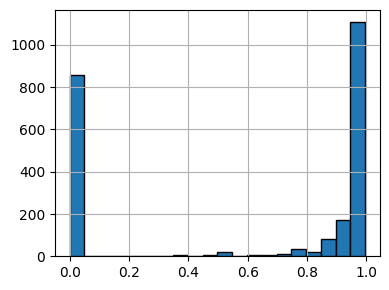

In [96]:
thresholds = list(dict_topic1_pro_threshold_m.values())
print(np.min(thresholds), np.median(thresholds), np.average(thresholds), np.max(thresholds), len(thresholds))
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.hist(thresholds, bins=20, edgecolor='black')
plt.grid(True)
plt.tight_layout()
plt.show()

In [97]:
print(len([t for t in thresholds if t<0.9 and t>0]), len([t for t in thresholds if t>=0.9]))
print(len([t for t in thresholds if t<0.95 and t>0]), len([t for t in thresholds if t>=0.95]))

199 1276
371 1104


In [98]:
lowest_threshold = 0.95
dict_topic_relation_m = check_topic_relation(method_pairwise_topic_similarity, dict_topic1_pro_threshold_m, lowest_threshold=lowest_threshold)

save_to_pickle(dict_topic_relation_m, f'data/dict_topic_relation_m_{lowest_threshold}.pkl')

  0%|                                                  | 0/2332 [00:00<?, ?it/s]

Genetic Analysis Techniques 27


  0%|                                        | 1/2332 [00:14<9:18:15, 14.37s/it]

Region Growing Technique 72


  0%|                                       | 2/2332 [00:46<15:55:26, 24.60s/it]

...

 98%|████████████████████████████████████▎| 2286/2332 [3:17:46<00:05,  8.55it/s]

Hyperbolic embeddings 1


 99%|████████████████████████████████████▍| 2299/2332 [3:17:47<00:02, 14.85it/s]

Probability distribution modeling 1


100%|█████████████████████████████████████| 2332/2332 [3:17:47<00:00,  5.09s/it]


In [99]:
dict_relation_count = Counter()
equal_rel = []
for topics, relation in dict_topic_relation_m.items():
    dict_relation_count[relation] += 1
    if relation == 'equal':
        print(topics)
        equal_rel.append(topics)
dict_relation_count

('Hyperparameter Optimization', 'Hyper-parameter Optimization')
('Hyper-spectral Imaging', 'Hyperspectral Imaging')
('Data Imputation Techniques', 'Missing Data Imputation')
('Similarity Measurement', 'Similarity Assessment')
('Optimization Algorithms', 'Optimization Techniques')
('Optimization Algorithms', 'Algorithmic Optimization Techniques')
('Optimization Algorithms', 'Algorithmic Optimization')
('Phylogenetic analysis focus', 'Dominant Phylogenetics Focus')
('Clustering Techniques', 'Cluster Analysis Techniques')
('Frequency analysis technique', 'Frequency-based Analysis')
('Frequency analysis technique', 'Frequency Information Analysis')
('Sparse signal estimation', 'Sparse Signal Recovery')
('Parallel computing techniques', 'Parallel Computing Focus')
('Molecular Docking Analysis', 'Molecular Docking Focus')
('Methodological Evaluation Techniques', 'Methodology Techniques Analysis')
('Observational Study Methods', 'Observational study methodology')
('Kernel Methods', 'Kernel-ba

Counter({'nooverlap': 12333, 'subset': 5042, 'superset': 3250, 'equal': 62})

In [100]:
topic_name_map_m = construct_equal_topic_map(dict_topic_relation_m)

In [101]:
merged_topic_relation_m = merge_equal_topics(dict_topic_relation_m)
subset_edges_m = extract_subset_relation(merged_topic_relation_m)
len(subset_edges_m)

8036

In [102]:
check_2nd_relation_m = double_check_subsumption_relation(subset_edges_m, reverse=True)
save_to_pickle(check_2nd_relation_m, f'data/check_2nd_relation_m_{lowest_threshold}.pkl')



IOPub message rate exceeded.                | 2999/8036 [25:04<37:06,  2.26it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [103]:
check_2nd_edge_subset_m = select_consistent_edge_subset(check_2nd_relation_m, reverse=True)

Counter({'superset': 4842, 'subset': 1965, 'nooverlap': 1165, 'equal': 10})


In [104]:
check_3rd_relation_m = double_check_subsumption_relation(check_2nd_edge_subset_m, reverse=False)
save_to_pickle(check_3rd_relation_m, f'data/check_3rd_relation_m_{lowest_threshold}.pkl')

IOPub message rate exceeded.█▏              | 2999/4842 [22:21<12:38,  2.43it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

100%|███████████████████████████████████████| 4842/4842 [37:06<00:00,  2.17it/s]


In [105]:
check_3rd_edge_subset_m = select_consistent_edge_subset(check_3rd_relation_m, reverse=False)

Counter({'subset': 3531, 'superset': 788, 'nooverlap': 514, 'equal': 9})


In [107]:
check_4th_relation_m = double_check_subsumption_relation(check_3rd_edge_subset_m, reverse=True)
save_to_pickle(check_4th_relation_m, f'data/check_4th_relation_m_{lowest_threshold}.pkl')

100%|███████████████████████████████████████| 3531/3531 [30:06<00:00,  1.95it/s]


In [138]:
check_4th_edge_subset_m = select_consistent_edge_subset(check_4th_relation_m, reverse=True)

Counter({'superset': 3154, 'subset': 343, 'nooverlap': 34})


In [139]:
# check_5th_relation_m = double_check_subsumption_relation(check_4th_edge_subset_m, reverse=False)
# save_to_pickle(check_5th_relation_m, f'data/check_5th_relation_m_{lowest_threshold}.pkl')

In [140]:
# check_5th_edge_subset_m = select_consistent_edge_subset(check_5th_relation_m, reverse=False)

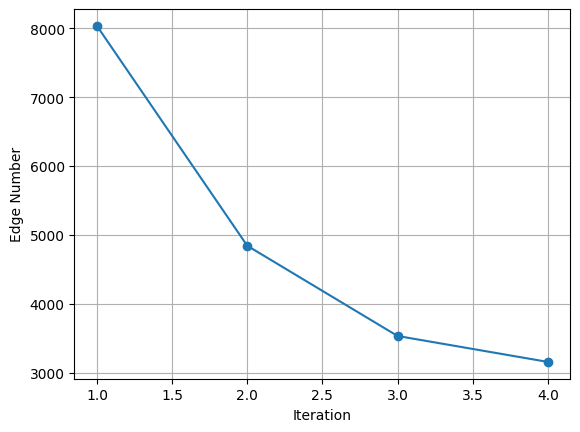

In [141]:
edge_nums = [len(subset_edges_m), len(check_2nd_edge_subset_m), len(check_3rd_edge_subset_m), 
             len(check_4th_edge_subset_m)]

x = np.arange(1, len(edge_nums) + 1)
y = edge_nums

plt.plot(x, y, marker='o')  # Optional: marker='o' to show points
plt.xlabel('Iteration')
plt.ylabel('Edge Number')
plt.grid(True)
plt.show()


In [142]:
all_cycles_m = find_all_cycles(subset_edges_m)
print(len(all_cycles_m))
all_cycles_m = find_all_cycles(check_2nd_edge_subset_m)
print(len(all_cycles_m))
all_cycles_m = find_all_cycles(check_3rd_edge_subset_m)
print(len(all_cycles_m))
all_cycles_m = find_all_cycles(check_4th_edge_subset_m)
print(len(all_cycles_m))
# all_cycles_m = find_all_cycles(check_5th_edge_subset_m)
# print(len(all_cycles_m))

2391
256
2
0


In [143]:
for idx, cycle in enumerate(all_cycles_m):
    print(idx, cycle)

In [144]:
low_level_immediate_edges_m = get_immediate_edges(check_4th_edge_subset_m)
print(len(check_4th_edge_subset_m), len(low_level_immediate_edges_m))
write_hierarchy_to_file(low_level_immediate_edges_m, 'method_subhierarchy.txt')

3154 2337
Hierarchy tree has been written to 'method_subhierarchy.txt'


In [145]:
high_level_topics_m = [topic for topic, threshold in dict_topic1_pro_threshold_m.items() if (threshold <= lowest_threshold and threshold>0)]
low_level_topics_m = [topic for topic, threshold in dict_topic1_pro_threshold_m.items() if (threshold > lowest_threshold)]
zero_threshold_topics_m = [topic for topic, threshold in dict_topic1_pro_threshold_m.items() if (threshold == 0)]
print(len(high_level_topics_m), len(low_level_topics_m), len(zero_threshold_topics_m))

371 1104 857


In [146]:
isolated_low_level_topics_m = set(low_level_topics_m) - set(find_all_nodes(low_level_immediate_edges_m))
print(len(isolated_low_level_topics_m))
low_level_root_topics_m = list(set(find_root_nodes(low_level_immediate_edges_m)).union(isolated_low_level_topics_m))
print(len(low_level_root_topics_m))

238
562


In [147]:
#Check if any high level node is in the subhierarchies but not a root node.
for topic in high_level_topics_m:
    if (topic not in low_level_root_topics_m) and (topic in low_level_topics_m):
        print(topic)

In [148]:
#Clean up high level topics by merging the equivalence
high_level_topics_merged_m = []
for topic in high_level_topics_m:
    if topic in topic_name_map_m.keys():
        print(topic, ",", topic_name_map_m[topic])
        high_level_topics_merged_m.append(topic_name_map_m[topic])
    else:
        high_level_topics_merged_m.append(topic)
high_level_topics_merged_m = list(set(high_level_topics_merged_m))
print(len(high_level_topics_merged_m), len(high_level_topics_m))

Statistical Analysis Techniques , Statistical Analysis Methods
Kernel-based Methods , Kernel Methods
Optimization Techniques , Algorithmic Optimization Techniques
Methodology Techniques Analysis , Methodological Evaluation Techniques
Hierarchical Clustering Methods , Hierarchical Clustering Analysis
Pattern-based Methods , Pattern Identification Techniques
371 371


In [118]:
len(set(high_level_topics_merged_m).intersection(set(low_level_root_topics_m)))

128

In [119]:
dict_topic_sim_high_level_m = compute_topic_similarity(high_level_topics_merged_m, low_level_root_topics_m)
print(len(dict_topic_sim_high_level_m))

computing cosine similarity...
253415


In [120]:
dict_high_level_topic_relation_m = check_high_level_topic_relation(method_pairwise_topic_similarity, dict_topic1_pro_threshold_m, dict_topic_sim_high_level_m)
save_to_pickle(dict_high_level_topic_relation_m, f'data/dict_high_level_topic_relation_m.pkl')



100%|██████████████████████████████████████| 371/371 [00:00<00:00, 34879.67it/s]
IOPub message rate exceeded.          | 15616/47978 [2:11:27<4:28:05,  2.01it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

100%|███████████████████████████████████| 47978/47978 [6:37:56<00:00,  2.01it/s]


In [122]:
dict_relation_count = Counter()
equal_rel = []
for topics, relation in dict_high_level_topic_relation_m.items():
    dict_relation_count[relation] += 1
    if relation == 'equal':
        print(topics)
        equal_rel.append(topics)
dict_relation_count

('Computational Biology', 'Computational Biology')
('Statistical Methodology Challenges', 'Statistical Methodology Challenges')
('Hyper-parameter Optimization', 'Hyperparameter Optimization')
('Biophysics Methodology', 'Biophysics Methodology')
('Pattern Identification Techniques', 'Pattern Recognition Techniques')
('Computer Vision', 'Computer Vision')
('Drug Identification Methods', 'Drug Identification Methods')
('Evaluation and Classification', 'Evaluation and Classification')
('Research Methodology Focus', 'Research Methods Focus')
('Research Methodology Focus', 'Research Methodology Focus')
('Pattern Recognition Techniques', 'Pattern Recognition Techniques')
('Deep Learning Focus', 'Deep Learning Focus')
('Measurement and Detection', 'Measurement and Detection')
('Machine Learning Algorithms', 'Machine Learning Algorithms')
('Analytical Frameworks', 'Analytical Frameworks')
('Functional Brain Imaging', 'Functional Brain Imaging')
('Natural Language Processing', 'Natural Language 

Counter({'nooverlap': 35020, 'superset': 6528, 'subset': 6261, 'equal': 169})

In [123]:
high_level_topic_name_map_m = construct_equal_topic_map(dict_high_level_topic_relation_m)
high_level_merged_topic_relation_m = merge_equal_topics(dict_high_level_topic_relation_m)
high_level_subset_edges_m = extract_subset_relation(high_level_merged_topic_relation_m)
len(high_level_subset_edges_m)

11114

In [124]:
high_level_check_2nd_relation_m = double_check_subsumption_relation(high_level_subset_edges_m, reverse=True)
save_to_pickle(high_level_check_2nd_relation_m, f'data/high_level_check_2nd_relation_m_{lowest_threshold}.pkl')



100%|███████████████████████████████████| 11114/11114 [1:47:07<00:00,  1.73it/s]


In [125]:
high_level_check_2nd_edge_subset_m = select_consistent_edge_subset(high_level_check_2nd_relation_m, reverse=True)

Counter({'superset': 6234, 'subset': 2094, 'nooverlap': 1814, 'equal': 6})


In [126]:
high_level_check_3rd_relation_m = double_check_subsumption_relation(high_level_check_2nd_edge_subset_m, reverse=False)
save_to_pickle(high_level_check_3rd_relation_m, f'data/high_level_check_3rd_relation_m_{lowest_threshold}.pkl')

100%|███████████████████████████████████████| 6234/6234 [58:46<00:00,  1.77it/s]


In [127]:
high_level_check_3rd_edge_subset_m = select_consistent_edge_subset(high_level_check_3rd_relation_m, reverse=False)

Counter({'subset': 4052, 'nooverlap': 1569, 'superset': 609, 'equal': 4})


In [129]:
high_level_check_4th_relation_m = double_check_subsumption_relation(high_level_check_3rd_edge_subset_m, reverse=True)
save_to_pickle(high_level_check_4th_relation_m, f'data/high_level_check_4th_relation_m_{lowest_threshold}.pkl')

100%|███████████████████████████████████████| 4052/4052 [31:38<00:00,  2.13it/s]


In [151]:
high_level_check_4th_edge_subset_m = select_consistent_edge_subset(high_level_check_4th_relation_m, reverse=True)

Counter({'superset': 3598, 'subset': 398, 'nooverlap': 56})


In [268]:
# high_level_check_5th_relation_m = double_check_subsumption_relation(high_level_check_4th_edge_subset_m, reverse=False)
# save_to_pickle(high_level_check_5th_relation_m, f'data/high_level_check_5th_relation_m_{lowest_threshold}.pkl')

In [269]:
# high_level_check_5th_edge_subset_m = select_consistent_edge_subset(high_level_check_5th_relation_m, reverse=False)

In [156]:
# # print(high_level_merged_topic_relation_m[('Data Management Challenges', 'Data Management')])
# print(high_level_check_2nd_relation_m[('Data Management Challenges', 'Data Management')])
# print(high_level_check_3rd_relation_m[('Data Management Challenges', 'Data Management')])
# # print(high_level_check_4rd_relation_m[('Data Management Challenges', 'Data Management')])
# print(high_level_check_4rd_relation_m[('Data Management', 'Data Management Challenges')])


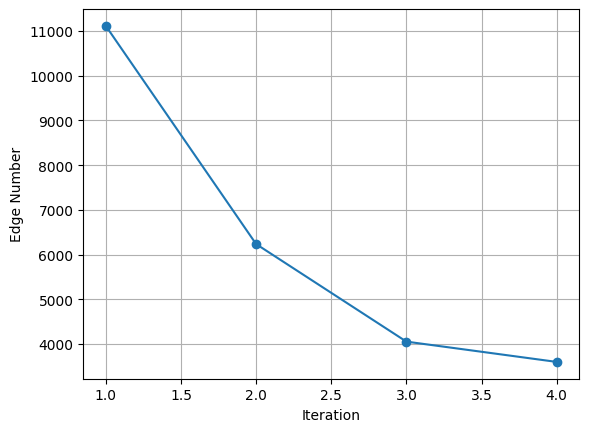

In [152]:
edge_nums = [len(high_level_subset_edges_m), len(high_level_check_2nd_edge_subset_m), len(high_level_check_3rd_edge_subset_m), 
             len(high_level_check_4th_edge_subset_m)]

x = np.arange(1, len(edge_nums) + 1)
y = edge_nums

plt.plot(x, y, marker='o')  # Optional: marker='o' to show points
plt.xlabel('Iteration')
plt.ylabel('Edge Number')
plt.grid(True)
plt.show()


In [153]:
all_cycles_m = find_all_cycles(high_level_subset_edges_m)
print(len(all_cycles_m))
all_cycles_m = find_all_cycles(high_level_check_2nd_edge_subset_m)
print(len(all_cycles_m))
all_cycles_m = find_all_cycles(high_level_check_3rd_edge_subset_m)
print(len(all_cycles_m))
all_cycles_m = find_all_cycles(high_level_check_4th_edge_subset_m)
print(len(all_cycles_m))
# all_cycles_m = find_all_cycles(high_level_check_5th_edge_subset_m)
# print(len(all_cycles_m))

5890
1284
4
1


In [154]:
all_cycles_m

[['Statistical Modeling Techniques', 'Data Modeling Techniques']]

In [155]:
edges_to_be_removed = [('Data Modeling Techniques', 'Statistical Modeling Techniques')]

high_level_check_4th_edge_subset_cleaned_m = list(set(high_level_check_4th_edge_subset_m) - set(edges_to_be_removed))
print(len(high_level_check_4th_edge_subset_cleaned_m), len(high_level_check_4th_edge_subset_m))
all_cycles_m = find_all_cycles(high_level_check_4th_edge_subset_cleaned_m)
print(all_cycles_m)

3597 3598
[]


In [156]:
high_level_immediate_edges_m = get_immediate_edges(high_level_check_4th_edge_subset_cleaned_m)
print(len(high_level_check_4th_edge_subset_cleaned_m), len(high_level_immediate_edges_m))
write_hierarchy_to_file(high_level_immediate_edges_m, 'high_level_method_subhierarchy.txt')

3597 1605
Hierarchy tree has been written to 'high_level_method_subhierarchy.txt'


In [186]:
immediate_edges_m = list(set(high_level_immediate_edges_m).union(set(low_level_immediate_edges_m)))

immediate_edges_cleaned_m = []
for edge in immediate_edges_m:
    child, parent = edge
    if child in topic_name_map_m.keys():
        child = topic_name_map_m[child]
        if child in high_level_topic_name_map_m.keys():
            child = high_level_topic_name_map_m[child]
    if parent in topic_name_map_m.keys():
        parent = topic_name_map_m[parent]
        if parent in high_level_topic_name_map_m.keys():
            parent = high_level_topic_name_map_m[parent]
    immediate_edges_cleaned_m.append((child, parent))
immediate_edges_cleaned_m = list(set(immediate_edges_cleaned_m))
print(len(immediate_edges_m), len(immediate_edges_cleaned_m))
all_cycles_m = find_all_cycles(immediate_edges_cleaned_m)
print(all_cycles_m)

3919 3883
[]


In [187]:
all_nodes = []
for topic in method_topic_name_list:
    if topic in topic_name_map_m.keys():
        topic_updated = topic_name_map_m[topic]
        print(f"1: {topic}->{topic_updated}")
        if topic_updated in high_level_topic_name_map_m.keys():
            topic_updated2 = high_level_topic_name_map_m[topic_updated]
            print(f"2: {topic_updated}->{topic_updated2}")
            all_nodes.append(topic_updated2)
        else:
            all_nodes.append(topic_updated)
    else:
        all_nodes.append(topic)
all_nodes = set(all_nodes)
print(len(all_nodes))

nodes_with_edge_m = find_all_nodes(immediate_edges_cleaned_m)
nodes_with_edge_m = set(nodes_with_edge_m)
print(len(nodes_with_edge_m))

isolated_topics_m = all_nodes - nodes_with_edge_m
print(len(isolated_topics_m))

1: Hyperparameter Optimization->Hyper-parameter Optimization
1: Similarity Measurement->Similarity Assessment
1: Optimization Algorithms->Algorithmic Optimization Techniques
1: Phylogenetic analysis focus->Dominant Phylogenetics Focus
1: Clustering Techniques->Cluster Analysis Techniques
1: Frequency analysis technique->Frequency Information Analysis
1: Sparse signal estimation->Sparse Signal Recovery
1: Parallel computing techniques->Parallel Computing Focus
1: Recommender Systems Focus->Recommendation Systems
1: Semisupervised Learning Methods->Semi-supervised learning
1: Clustering Techniques Analysis->Cluster Analysis Techniques
1: Unsupervised Learning Techniques->Unsupervised Learning Methods
1: Optimization Algorithms Focus->Algorithmic Optimization Techniques
1: Meta-analysis techniques->Meta Analysis Focus
1: Meta-analysis Focus->Meta Analysis Focus
1: Privacy-Preserving Techniques->Privacy Preservation Techniques
1: Classification Techniques->Classification Methods
2: Classif

In [203]:
top_root = 'Methodology Innovation'
write_hierarchy_with_isolated_nodes_to_file(immediate_edges_cleaned_m, isolated_topics_m, top_root, 'method_hierarchy.txt')

Hierarchy tree has been written to 'method_hierarchy.txt'


In [201]:
# root_nodes = find_root_nodes(immediate_edges_cleaned_m)
# print("number of root nodes (isolatd nodes excluded):", len(root_nodes))
# print("number of root nodes (isolatd nodes included):", len(root_nodes)+ len(isolated_topics_m))

# print(sorted(root_nodes))
# # for rn in sorted(root_nodes):
# #     print(rn)
# max_depth = get_max_depth(immediate_edges_cleaned_m)
# print("max_depth:", max_depth)

In [202]:
# len(immediate_edges_cleaned_m)

In [192]:
topic_names_cleaned_reversed_m = {id_: name for name, ids in topic_names_cleaned_m.items() for id_ in ids}

In [193]:
dict_final_topic_name2keywords_m = defaultdict(set)
for idx, topic in topic_names_cleaned_reversed_m.items():
    keywords = list(dict_topic_keyword_count_m[idx].keys())
    
    merged_topic = stemmed2original_name_m[topic]
    if merged_topic in topic_name_map_m.keys():
        topic_updated = topic_name_map_m[merged_topic]
        # print("1:", merged_topic, "->", topic_updated, "STEM:", topic, "ID:", idx, "orig:", topic_names_m[idx])
        if topic_updated in high_level_topic_name_map_m.keys():
            topic_updated2 = high_level_topic_name_map_m[topic_updated]
            # print("2:", topic_updated, "->", topic_updated2,  "STEM:", topic, "ID:", idx,"orig:", topic_names_m[idx])
            dict_final_topic_name2keywords_m[topic_updated2].update(keywords)
        else:
            dict_final_topic_name2keywords_m[topic_updated].update(keywords)
    else:
        dict_final_topic_name2keywords_m[merged_topic].update(keywords)


            
print(len(dict_final_topic_name2keywords_m))

# assert len(all_nodes) == len(dict_final_topic_name2keywords_m)

save_to_pickle(dict_final_topic_name2keywords_m, f'data/dict_final_topic_name2keywords_m.pkl')


2275


In [194]:
tmp_selected = []
for topic in dict_final_topic_name2keywords_m.keys():
    if 'information' in topic.lower():
        tmp_selected.append(topic)

set(tmp_selected)

{'Automated Information Systems',
 'Clinical information systems',
 'Frequency Information Analysis',
 'Healthcare Information Systems',
 'Information Extraction',
 'Information Extraction Techniques',
 'Information Fusion Techniques',
 'Information Loss Measurement',
 'Information Management',
 'Information Retrieval Challenges',
 'Information Retrieval Methods',
 'Information Retrieval Techniques',
 'Information Security Focus',
 'Information Security Practices',
 'Information Storage Dominance',
 'Information Structuring',
 'Information Systems',
 'Information Systems Evaluation',
 'Information Technology',
 'Information Technology Systems',
 'Information Theory',
 'Information Theory Dominance',
 'Information retrieval systems',
 'Medical Information Systems'}